### Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_csv('wine.csv')

In [3]:
df.shape

(178, 14)

In [4]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
## duplicates values
df.duplicated().sum()

np.int64(0)

In [7]:
## missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

<Axes: >

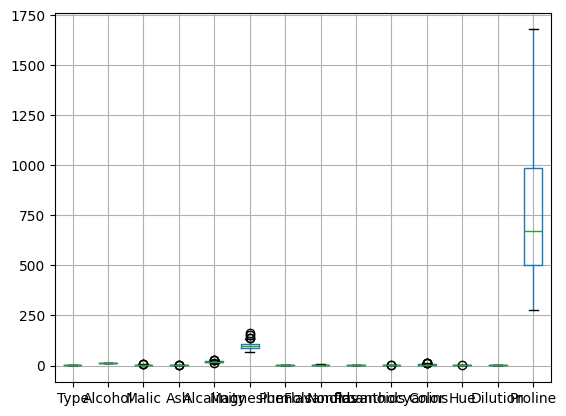

In [8]:
## detection of outliers
df.boxplot()

In [9]:
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+ 1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

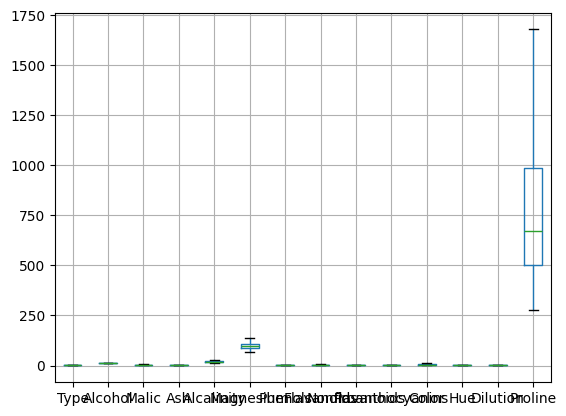

In [10]:
df.boxplot()
plt.show()

In [11]:
target=df[['Type']]
features=df.drop(columns=['Type'])

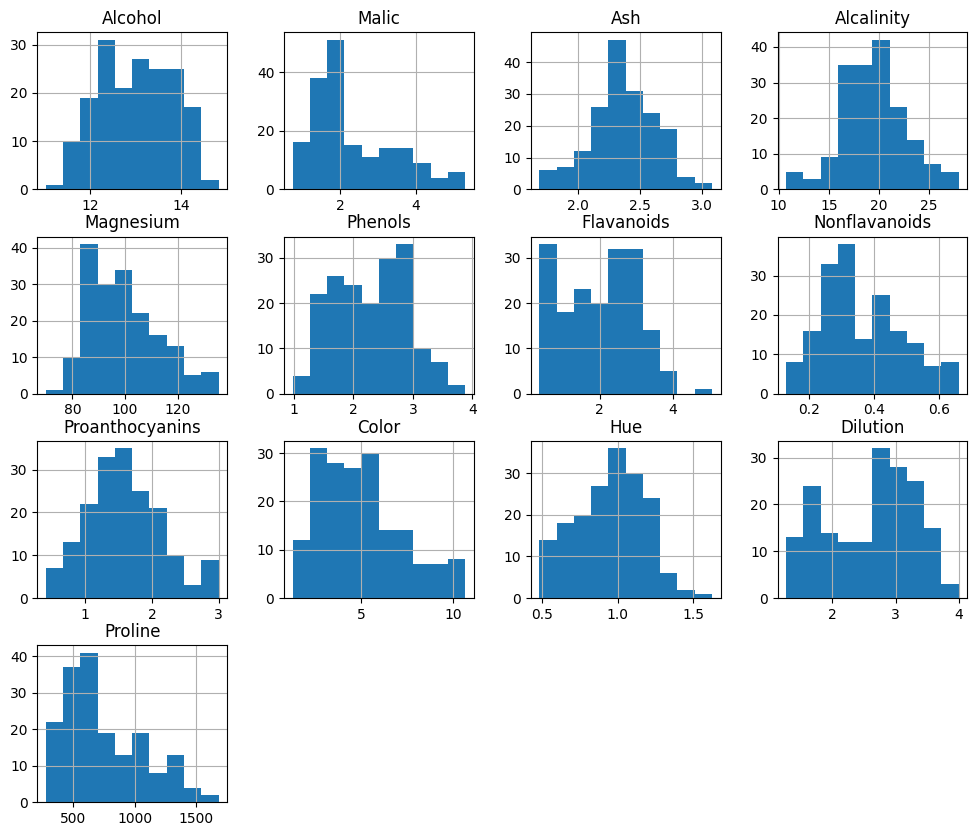

In [12]:
features.hist(figsize=(12,10))
plt.show()

In [13]:
corr=features.corr()

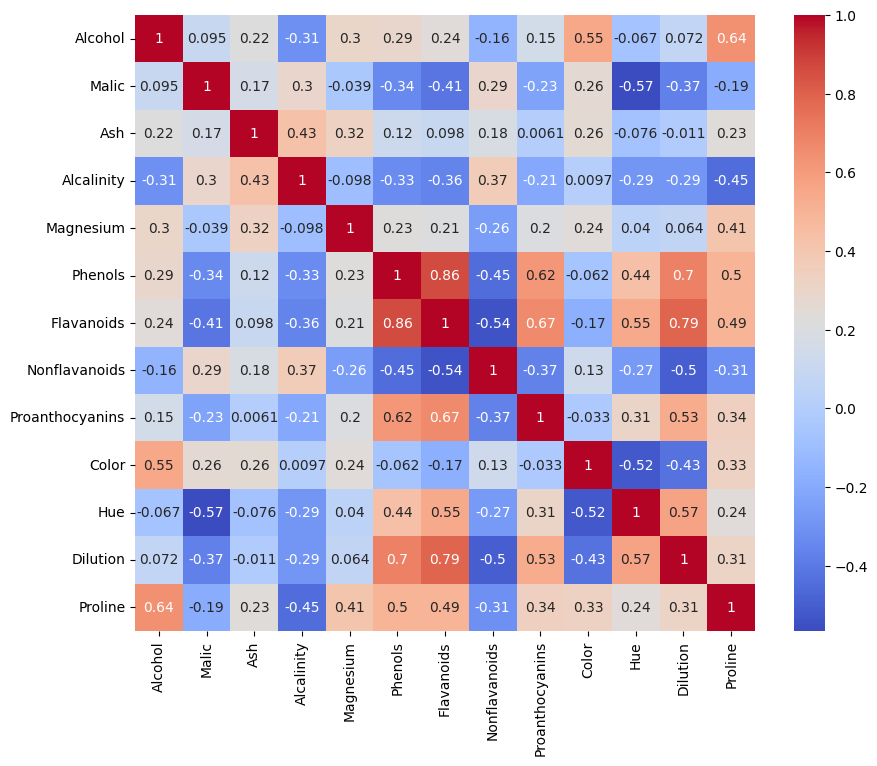

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components.


In [15]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(142, 13)
(36, 13)
(142, 1)
(36, 1)


In [16]:
x_train.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
111,12.52,2.43,2.17,21.0,88.0,2.55,2.27,0.26,1.22,2.00,0.90,2.78,325
119,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.28,0.93,3.05,564
170,12.20,3.03,2.32,19.0,96.0,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520
29,14.02,1.68,2.21,16.0,96.0,2.65,2.33,0.26,1.98,4.70,1.04,3.59,1035


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


In [26]:
pca=PCA(n_components=10)

In [27]:
x_train_new=pca.fit_transform(x_train)
x_test_new=pca.transform(x_test)

In [28]:
print(x_train_new.shape)
print(x_test_new.shape)

(142, 10)
(36, 10)


In [29]:
log_model=LogisticRegression()
log_model.fit(x_train_new,y_train)
y_pred=log_model.predict(x_test_new)
accuracy_score(y_test,y_pred)

0.9444444444444444

In [30]:
pca.explained_variance_ratio_

array([9.98628613e-01, 1.21898210e-03, 8.63181127e-05, 4.14690673e-05,
       1.01186843e-05, 8.23599831e-06, 2.80627687e-06, 1.19274729e-06,
       1.10700961e-06, 5.55301706e-07])

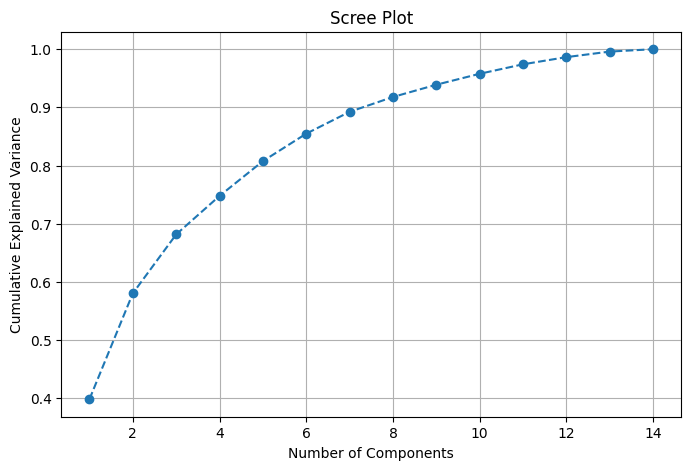

In [31]:
# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()

### Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.


In [32]:
from sklearn.preprocessing import StandardScaler
std_sca=StandardScaler()
features=pd.DataFrame(std_sca.fit_transform(features),columns=features.columns)
features.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874


In [33]:
kmeans=KMeans(n_clusters=3)
clusters=kmeans.fit(features)
clusters.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

In [34]:
np.unique(clusters.labels_)

array([0, 1, 2], dtype=int32)

In [35]:
silhouette_score(features,clusters.labels_)

np.float64(0.2864118609938738)

In [36]:
df['clusters']=clusters.labels_

In [37]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,clusters
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [38]:
df[df.clusters==0]

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,clusters
61,2,12.64,1.3600,2.02,16.8,100.0,2.02,1.41,0.53,0.62,5.750000,0.98,1.59,450,0
83,2,13.05,3.8600,2.32,22.5,85.0,1.65,1.59,0.61,1.62,4.800000,0.84,2.01,515,0
118,2,12.77,3.4300,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.400000,0.70,2.12,372,0
130,3,12.86,1.3500,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.100000,0.76,1.29,630,0
131,3,12.88,2.9900,2.40,20.0,104.0,1.30,1.22,0.24,0.83,5.400000,0.74,1.42,530,0
132,3,12.81,2.3100,2.40,24.0,98.0,1.15,1.09,0.27,0.83,5.700000,0.66,1.36,560,0
133,3,12.70,3.5500,2.36,21.5,106.0,1.70,1.20,0.17,0.84,5.000000,0.78,1.29,600,0
134,3,12.51,1.2400,2.25,17.5,85.0,2.00,0.58,0.60,1.25,5.450000,0.75,1.51,650,0
135,3,12.60,2.4600,2.20,18.5,94.0,1.62,0.66,0.63,0.94,7.100000,0.73,1.58,695,0
136,3,12.25,4.7200,2.54,21.0,89.0,1.38,0.47,0.53,0.80,3.850000,0.75,1.27,720,0


In [39]:
df[df.clusters==1]

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,clusters
59,2,12.37,0.94,1.68875,10.75,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520,1
60,2,12.33,1.10,2.28000,16.00,101.0,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,1
62,2,13.67,1.25,1.92000,18.00,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630,1
63,2,12.37,1.13,2.16000,19.00,87.0,3.50,3.10,0.19,1.87,4.45,1.22,2.87,420,1
64,2,12.17,1.45,2.53000,19.00,104.0,1.89,1.75,0.45,1.03,2.95,1.45,2.23,355,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2,12.07,2.16,2.17000,21.00,85.0,2.60,2.65,0.37,1.35,2.76,0.86,3.28,378,1
126,2,12.43,1.53,2.29000,21.50,86.0,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352,1
127,2,11.79,2.13,2.78000,27.95,92.0,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466,1
128,2,12.37,1.63,2.30000,24.50,88.0,2.22,2.45,0.40,1.90,2.12,0.89,2.78,342,1


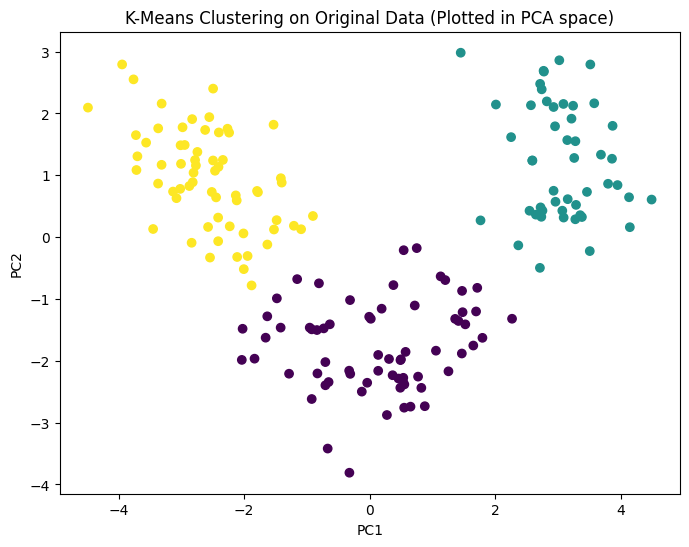

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters_orig, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering on Original Data (Plotted in PCA space)')
plt.show()

### Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.


In [50]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(pca_data)
score_pca = silhouette_score(pca_data, clusters_pca)
print("Silhouette Score (PCA Data):", score_pca)

Silhouette Score (PCA Data): 0.3234461099022564


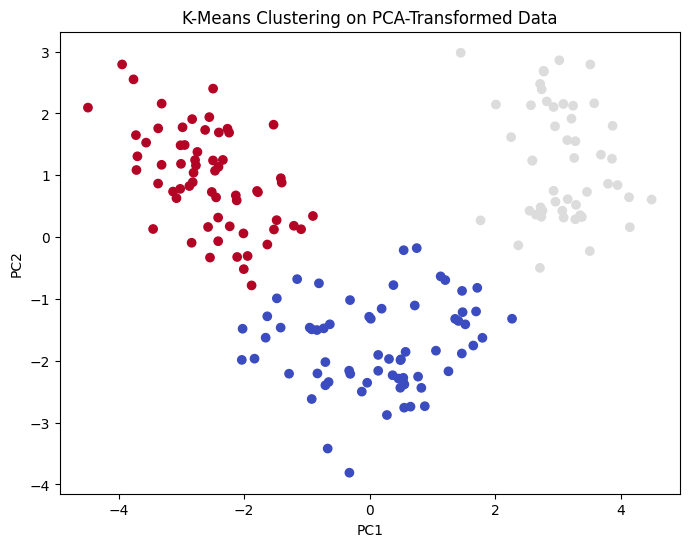

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters_pca, cmap='coolwarm')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering on PCA-Transformed Data')
plt.show()

### Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.


### Task 6: Conclusion and Insights
1.	Summarize the key findings and insights from the assignment.
2.	Discuss the practical implications of using PCA and clustering in data analysis.
3.	Provide recommendations for when to use each technique based on the analysis conducted.
